In [1]:
import sys
import h5py
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#auroc per cell

In [3]:
eva_cell=pd.read_csv('./Metric_cell.csv',index_col=0).T
eva_cell

,auroc_cell
0,0.791558
1,0.831024
2,0.880418
3,0.848421
4,0.856094
...,...
4999,0.780899
5000,0.779341
5001,0.792415
5002,0.787369


In [4]:
auroc_cell=eva_cell['auroc_cell']

In [5]:
import numpy as np

In [6]:
np.median([x for x in auroc_cell if x!=0])

0.7453153830726033

In [7]:
np.mean([x for x in auroc_cell if x!=0])

0.7561299030606052

In [8]:
#auroc per peak

In [9]:
eva_peak=pd.read_csv('./Metric_peak.csv',index_col=0).T
eva_peak

,auroc_peak
0,0.745527
1,0.626220
2,0.931531
3,0.877033
4,0.719369
...,...
26737,0.940019
26738,0.764468
26739,0.838305
26740,0.674830


In [10]:
auroc_peak=eva_peak['auroc_peak']

In [11]:
np.median([x for x in auroc_peak if x!=0])

0.735403920530211

In [12]:
np.mean([x for x in auroc_peak if x!=0])

0.7301825363344628

In [13]:
#cell embedding 

In [14]:
w=np.load('./cellembed.npy')
w.shape

(5004, 5005)

In [15]:
meta=pd.read_csv('Humanbrain.sample.anno.csv')
meta

,cellID,sample,replicate,logUMI,tsse,tissue,cell type,Life stage,class
0,Human_brain_1_1+AGCGATAGAACCAGGTAATGACGTGTACTGAC,Human_brain_1_1,1,3.701827,13.956466,Human_brain_1,Microglia,Adult,NonN
1,Human_brain_1_1+AGCGATAGAGGCAGAAACTGCATACAGGACGT,Human_brain_1_1,1,3.246006,13.888889,Human_brain_1,Microglia,Adult,NonN
2,Human_brain_1_1+AGCGATAGATAAGTCGTCCGGTAACCTATCCT,Human_brain_1_1,1,3.134177,27.505828,Human_brain_1,Microglia,Adult,NonN
3,Human_brain_1_1+AGCGATAGCGCTTGATGGTTAGACTAATCTTA,Human_brain_1_1,1,3.582518,10.432191,Human_brain_1,Microglia,Adult,NonN
4,Human_brain_1_1+AGCGATAGCTCTCTACCTAAGCCTAGGCGAAG,Human_brain_1_1,1,3.266467,17.851240,Human_brain_1,Microglia,Adult,NonN
...,...,...,...,...,...,...,...,...,...
4999,Human_brain_2_1+TGTTACCAGCGTAGTAAAGGCTATGTCA,Human_brain_2_1,1,3.262925,15.987461,Human_brain_2,Astrocyte 1,Adult,NonN
5000,Human_brain_2_1+TGTTACCAGTCTACCATAAGATCCAACG,Human_brain_2_1,1,3.449787,7.616708,Human_brain_2,Astrocyte 1,Adult,NonN
5001,Human_brain_2_1+TGTTACCATAAGGCGAGTAAGGAGGGCT,Human_brain_2_1,1,3.306425,8.717310,Human_brain_2,Astrocyte 1,Adult,NonN
5002,Human_brain_2_1+TGTTACCATACTGCCTAGGATAACAACG,Human_brain_2_1,1,3.148294,14.545455,Human_brain_2,Astrocyte 1,Adult,NonN


In [16]:
ad=sc.AnnData(w)

ad.obs['anno']=list(meta['cell type'])
ad
ad.obsm['projection']=w

In [17]:
ad

AnnData object with n_obs × n_vars = 5004 × 5005
    obs: 'anno'
    obsm: 'projection'

In [18]:
sc.pp.neighbors(ad, use_rep='projection')
sc.tl.umap(ad)

/home/ggj/anaconda3/envs/scvi-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/ggj/anaconda3/envs/scvi-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


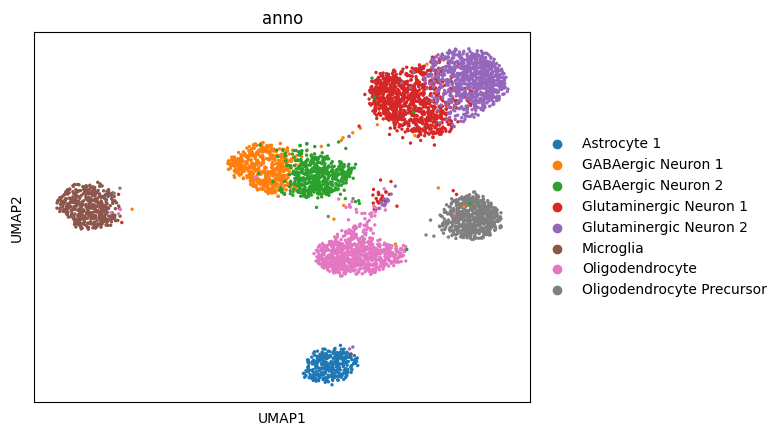

In [19]:
sc.pl.umap(ad, color=['anno'])

In [20]:
sc.tl.leiden(ad,resolution=0.6)

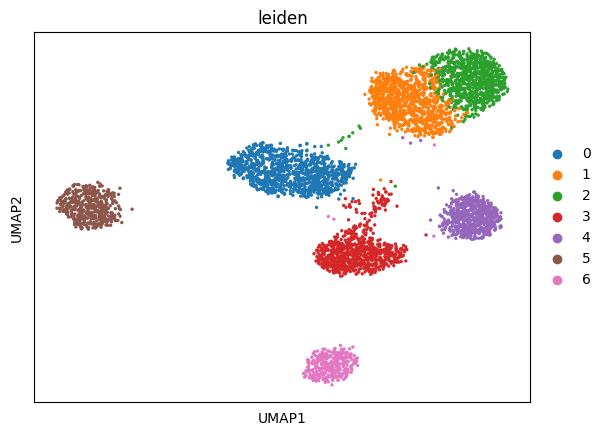

In [21]:
sc.pl.umap(ad, color=['leiden'])

In [ ]:
ad.write('cell_embedding.h5ad')

In [22]:
import sklearn.metrics
from sklearn.metrics import silhouette_score
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

In [ ]:
sil=silhouette_score(ad.obsm['X_umap'], ad.obs['leiden'])
sil

In [23]:
ami=sklearn.metrics.adjusted_mutual_info_score(ad.obs['anno'].values.astype(str),ad.obs['leiden'].values.astype(str))
ami

0.8597084011144233

In [24]:
ari=adjusted_rand_score(ad.obs['anno'].values.astype(str),ad.obs['leiden'].values.astype(str))
ari

0.8062320404916473

In [25]:
nmi=normalized_mutual_info_score(ad.obs['anno'].values.astype(str),ad.obs['leiden'].values.astype(str))
nmi

0.8600120820190683